In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy.stats import norm
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#f9f9f9',
    'axes.grid': True,
    'grid.alpha': 0.4,
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})

COLORS = {
    'portfolio': '#1a3a5c',
    'agg':       '#c0392b',
    'sp500':     '#27ae60',
    'accent':    '#e67e22',
    'neutral':   '#7f8c8d',
}

In [2]:
START = '2016-01-01'
END   = '2021-03-31'
RISK_FREE_ANNUAL = 0.02
RF_DAILY = RISK_FREE_ANNUAL / 252
TRADING_DAYS = 252
TARGET_RETURN = 0.05
MAX_DRAWDOWN  = -0.08
FUND_VALUE    = 10_000_000

CANDIDATES = {
    'TIPS':         ['SCHP', 'VTIP', 'TIP'],
    'Treasury':     ['BND',  'GOVT', 'IEF'],
    'IG Corporate': ['LQD',  'VCIT', 'IGIB'],
    'US Large Cap': ['VOO',  'IVV',  'SPY'],
    'Intl Dev':     ['EFA',  'VEA',  'IDEV'],
    'Cash Equiv':   ['SHV',  'BIL',  'SGOV'],
}

BENCHMARKS = {'AGG': 'AGG', 'SPY': 'SPY'}


In [3]:
all_tickers = list(set([t for g in CANDIDATES.values() for t in g] + list(BENCHMARKS.values())))
print(f"Downloading {len(all_tickers)} tickers...")
raw = yf.download(all_tickers, start=START, end=END, auto_adjust=True, progress=False)['Close']

missing = raw.isnull().mean()
dropped = missing[missing > 0.05].index.tolist()
if dropped:
    print(f"Dropped (insufficient data): {dropped}")
raw = raw.drop(columns=dropped, errors='ignore')

prices  = raw.ffill().dropna()
returns = prices.pct_change().dropna()
print(f"Clean matrix: {prices.shape[0]} days × {prices.shape[1]} tickers")
print(f"Period: {prices.index[0].date()} → {prices.index[-1].date()}")

Dropped (insufficient data): ['IDEV', 'SGOV']
Clean matrix: 1319 days × 17 tickers
Period: 2016-01-04 → 2021-03-30


In [4]:
def screen_etf(ticker, returns_df):
    if ticker not in returns_df.columns:
        return None
    r = returns_df[ticker].dropna()
    if len(r) < 200:
        return None
    n_years    = len(r) / TRADING_DAYS
    cum_return = (1 + r).prod() - 1
    ann_return = (1 + cum_return) ** (1 / n_years) - 1
    ann_vol    = r.std() * np.sqrt(TRADING_DAYS)
    sharpe     = (ann_return - RISK_FREE_ANNUAL) / ann_vol
    cum_val    = (1 + r).cumprod()
    rolling_max = cum_val.cummax()
    drawdowns  = (cum_val - rolling_max) / rolling_max
    max_dd     = drawdowns.min()
    calmar     = ann_return / abs(max_dd) if max_dd != 0 else np.nan
    var_95     = norm.ppf(0.05, r.mean(), r.std())
    return {
        'Ann. Return (Geo)%': round(ann_return * 100, 2),
        'Ann. Volatility%':   round(ann_vol * 100, 2),
        'Sharpe Ratio':       round(sharpe, 3),
        'Max Drawdown%':      round(max_dd * 100, 2),
        'VaR 95% Daily%':     round(var_95 * 100, 3),
    }

In [5]:
all_results = {}
for sleeve, tickers in CANDIDATES.items():
    for t in tickers:
        m = screen_etf(t, returns)
        if m:
            all_results[t] = m

screen_df = pd.DataFrame(all_results).T
screen_df.index.name = 'Ticker'
print("\n=== ETF SCREENING RESULTS ===")
print(screen_df.to_string())



=== ETF SCREENING RESULTS ===
        Ann. Return (Geo)%  Ann. Volatility%  Sharpe Ratio  Max Drawdown%  VaR 95% Daily%
Ticker                                                                                   
SCHP                  4.45              5.02         0.487         -10.85          -0.502
VTIP                  2.83              2.66         0.312          -6.27          -0.264
TIP                   4.34              5.23         0.447         -11.20          -0.524
BND                   3.66              4.92         0.338          -8.67          -0.495
GOVT                  2.55              4.27         0.129          -6.37          -0.432
IEF                   3.02              5.37         0.190          -8.82          -0.544
LQD                   5.82              8.56         0.446         -21.76          -0.863
VCIT                  5.20              5.85         0.548         -16.86          -0.585
IGIB                  4.89              5.38         0.537         -1

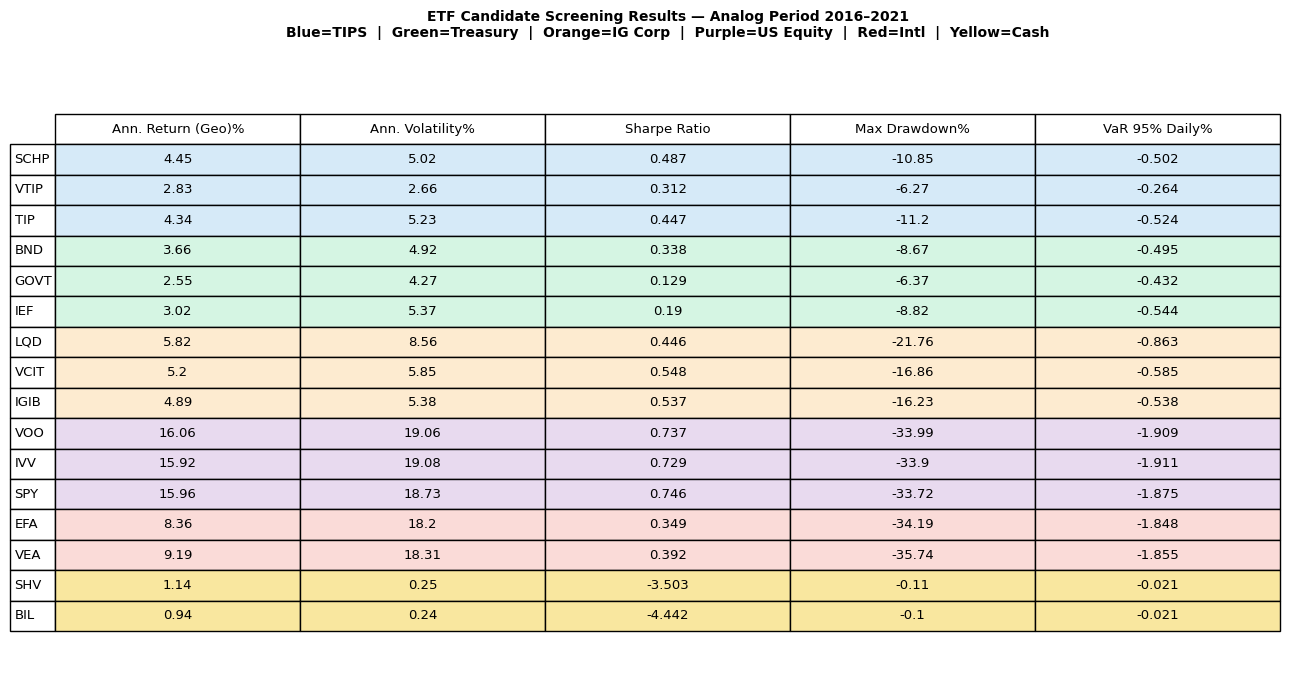

Saved: fig1_etf_screening_table.png


In [6]:
ticker_to_sleeve = {t: s for s, tickers in CANDIDATES.items() for t in tickers}
sleeve_colors = {
    'TIPS':         '#d6eaf8',
    'Treasury':     '#d5f5e3',
    'IG Corporate': '#fdebd0',
    'US Large Cap': '#e8daef',
    'Intl Dev':     '#fadbd8',
    'Cash Equiv':   '#f9e79f',
}
row_colors = [
    [sleeve_colors.get(ticker_to_sleeve.get(idx, ''), 'white')] * len(screen_df.columns)
    for idx in screen_df.index
]

fig, ax = plt.subplots(figsize=(13, 7))
ax.axis('off')
tbl = ax.table(
    cellText=screen_df.values.tolist(),
    rowLabels=screen_df.index.tolist(),
    colLabels=list(screen_df.columns),
    cellLoc='center', loc='center',
    cellColours=row_colors,
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(9.5)
tbl.scale(1, 1.6)
ax.set_title(
    'ETF Candidate Screening Results — Analog Period 2016–2021\n'
    'Blue=TIPS  |  Green=Treasury  |  Orange=IG Corp  |  Purple=US Equity  |  Red=Intl  |  Yellow=Cash',
    fontsize=10, pad=20, fontweight='bold'
)
plt.tight_layout()
plt.savefig('fig1_etf_screening_table.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fig1_etf_screening_table.png")


In [10]:
FINAL_PORTFOLIO = {
    'SCHP': {'sleeve': 'TIPS',         'weight': 0.25},
    'GOVT': {'sleeve': 'Treasury',     'weight': 0.25},
    'LQD':  {'sleeve': 'IG Corporate', 'weight': 0.20},
    'VOO':  {'sleeve': 'US Large Cap', 'weight': 0.12},
    'VEA':  {'sleeve': 'Intl Dev',     'weight': 0.08},
    'SHV':  {'sleeve': 'Cash Equiv',   'weight': 0.10},
}
weights = {t: d['weight'] for t, d in FINAL_PORTFOLIO.items()}
print(f"\nWeight check: {sum(weights.values()):.2f}")
for t, d in FINAL_PORTFOLIO.items():
    print(f"  {t:6s} | {d['sleeve']:14s} | {d['weight']*100:.0f}%")


Weight check: 1.00
  SCHP   | TIPS           | 25%
  GOVT   | Treasury       | 25%
  LQD    | IG Corporate   | 20%
  VOO    | US Large Cap   | 12%
  VEA    | Intl Dev       | 8%
  SHV    | Cash Equiv     | 10%


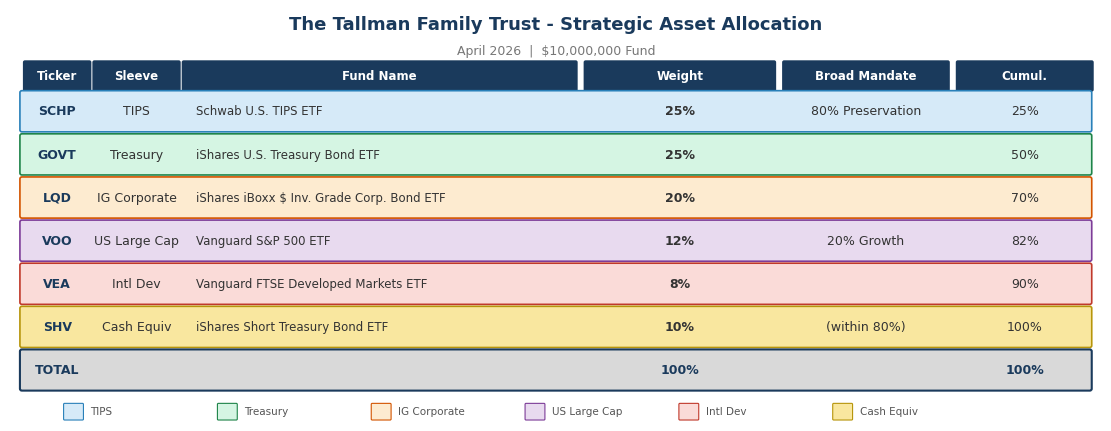

Saved: fig_allocation_table.png


In [12]:
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch

sleeve_colors = {
    'TIPS':         '#D6EAF8',
    'Treasury':     '#D5F5E3',
    'IG Corporate': '#FDEBD0',
    'US Large Cap': '#E8DAEF',
    'Intl Dev':     '#FADBD8',
    'Cash Equiv':   '#F9E79F',
}

border_colors = {
    'TIPS':         '#2980B9',
    'Treasury':     '#1E8449',
    'IG Corporate': '#D35400',
    'US Large Cap': '#7D3C98',
    'Intl Dev':     '#C0392B',
    'Cash Equiv':   '#B7950B',
}

rows = [
    ('SCHP', 'TIPS',         'Schwab U.S. TIPS ETF',                    '25%', '80% Preservation'),
    ('GOVT', 'Treasury',     'iShares U.S. Treasury Bond ETF',           '25%', ''),
    ('LQD',  'IG Corporate', 'iShares iBoxx $ Inv. Grade Corp. Bond ETF','20%', ''),
    ('VOO',  'US Large Cap', 'Vanguard S&P 500 ETF',                     '12%', '20% Growth'),
    ('VEA',  'Intl Dev',     'Vanguard FTSE Developed Markets ETF',       '8%', ''),
    ('SHV',  'Cash Equiv',   'iShares Short Treasury Bond ETF',          '10%', '(within 80%)'),
]

fig, ax = plt.subplots(figsize=(11, 4.2))
ax.set_xlim(0, 11)
ax.set_ylim(0, 4.2)
ax.axis('off')
fig.patch.set_facecolor('white')

ax.text(5.5, 4.05, 'The Tallman Family Trust - Strategic Asset Allocation',
        ha='center', va='center', fontsize=13, fontweight='bold', color='#1A3A5C',
        fontfamily='DejaVu Sans')
ax.text(5.5, 3.78, 'April 2026  |  $10,000,000 Fund',
        ha='center', va='center', fontsize=9, color='#777777', fontfamily='DejaVu Sans')

col_x    = [0.15, 0.85, 1.75, 5.80, 7.80, 9.55]
col_w    = [0.65, 0.85, 3.95, 1.90, 1.65, 1.35]
headers  = ['Ticker', 'Sleeve', 'Fund Name', 'Weight', 'Broad Mandate', 'Cumul.']
header_y = 3.38
header_h = 0.28

for i, (x, w, h) in enumerate(zip(col_x, col_w, headers)):
    rect = FancyBboxPatch((x, header_y), w, header_h,
                          boxstyle='round,pad=0.02', linewidth=0,
                          facecolor='#1A3A5C', zorder=2)
    ax.add_patch(rect)
    ax.text(x + w/2, header_y + header_h/2, h,
            ha='center', va='center', fontsize=8.5, fontweight='bold',
            color='white', fontfamily='DejaVu Sans', zorder=3)

row_h   = 0.44
row_y0  = header_y - row_h
cumul   = 0

for idx, (ticker, sleeve, name, wt, mandate) in enumerate(rows):
    y     = row_y0 - idx * row_h
    bg    = sleeve_colors[sleeve]
    bc    = border_colors[sleeve]
    pct   = float(wt.strip('%')) / 100
    cumul += pct * 100

    rect = FancyBboxPatch((0.12, y + 0.03), 10.76, row_h - 0.06,
                          boxstyle='round,pad=0.02', linewidth=1.2,
                          edgecolor=bc, facecolor=bg, zorder=2)
    ax.add_patch(rect)

    values = [ticker, sleeve, name, wt, mandate, f'{cumul:.0f}%']
    aligns = ['center','center','left','center','center','center']
    offsets = [0, 0, 0.12, 0, 0, 0]

    for i, (x, w, val, ha, off) in enumerate(zip(col_x, col_w, values, aligns, offsets)):
        fw = 'bold' if i in (0, 3) else 'normal'
        fs = 9 if i != 2 else 8.5
        col = '#1A3A5C' if i == 0 else '#333333'
        ax.text(x + (off if ha=='left' else w/2), y + row_h/2, val,
                ha=ha, va='center', fontsize=fs, fontweight=fw,
                color=col, fontfamily='DejaVu Sans', zorder=3)

total_y = row_y0 - len(rows) * row_h
rect = FancyBboxPatch((0.12, total_y + 0.03), 10.76, row_h - 0.06,
                      boxstyle='round,pad=0.02', linewidth=1.5,
                      edgecolor='#1A3A5C', facecolor='#D9D9D9', zorder=2)
ax.add_patch(rect)
ax.text(col_x[0] + col_w[0]/2, total_y + row_h/2, 'TOTAL',
        ha='center', va='center', fontsize=9, fontweight='bold',
        color='#1A3A5C', fontfamily='DejaVu Sans', zorder=3)
ax.text(col_x[3] + col_w[3]/2, total_y + row_h/2, '100%',
        ha='center', va='center', fontsize=9, fontweight='bold',
        color='#1A3A5C', fontfamily='DejaVu Sans', zorder=3)
ax.text(col_x[5] + col_w[5]/2, total_y + row_h/2, '100%',
        ha='center', va='center', fontsize=9, fontweight='bold',
        color='#1A3A5C', fontfamily='DejaVu Sans', zorder=3)

legend_y = total_y - 0.28
chip_w, chip_h, gap = 0.18, 0.15, 1.55
for i, (sleeve, bg) in enumerate(sleeve_colors.items()):
    lx = 0.55 + i * gap
    rect = FancyBboxPatch((lx, legend_y), chip_w, chip_h,
                          boxstyle='round,pad=0.01', linewidth=0.8,
                          edgecolor=border_colors[sleeve], facecolor=bg, zorder=2)
    ax.add_patch(rect)
    ax.text(lx + chip_w + 0.08, legend_y + chip_h/2, sleeve,
            ha='left', va='center', fontsize=7.5, color='#555555',
            fontfamily='DejaVu Sans', zorder=3)

plt.tight_layout(pad=0.3)
plt.savefig('fig_allocation_table.png', dpi=180, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()
print("Saved: fig_allocation_table.png")

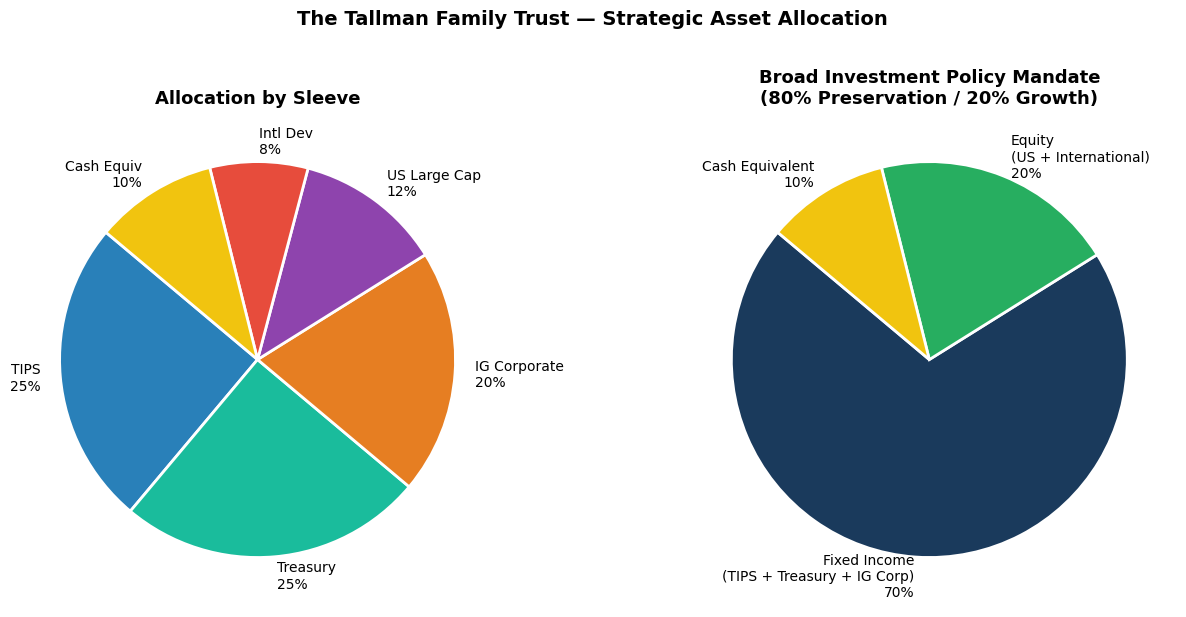

Saved: fig2_asset_allocation_pie.png


In [9]:
sleeve_weights = {}
for t, d in FINAL_PORTFOLIO.items():
    sleeve_weights[d['sleeve']] = sleeve_weights.get(d['sleeve'], 0) + d['weight']

pie_colors = ['#2980b9','#1abc9c','#e67e22','#8e44ad','#e74c3c','#f1c40f']
fig, axes = plt.subplots(1, 2, figsize=(13, 6))

axes[0].pie(
    sleeve_weights.values(),
    labels=[f"{s}\n{w*100:.0f}%" for s, w in sleeve_weights.items()],
    colors=pie_colors, startangle=140,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2},
    textprops={'fontsize': 10},
)
axes[0].set_title('Allocation by Sleeve', fontweight='bold')

broad = {'Fixed Income\n(TIPS + Treasury + IG Corp)': 0.70,
         'Equity\n(US + International)': 0.20,
         'Cash Equivalent': 0.10}
axes[1].pie(
    broad.values(),
    labels=[f"{k}\n{v*100:.0f}%" for k, v in broad.items()],
    colors=['#1a3a5c','#27ae60','#f1c40f'], startangle=140,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2},
    textprops={'fontsize': 10},
)
axes[1].set_title('Broad Investment Policy Mandate\n(80% Preservation / 20% Growth)', fontweight='bold')

plt.suptitle('The Tallman Family Trust — Strategic Asset Allocation', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig2_asset_allocation_pie.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fig2_asset_allocation_pie.png")

In [13]:
available = [t for t in weights if t in returns.columns]
missing_p = [t for t in weights if t not in returns.columns]
if missing_p:
    print(f"WARNING missing from price data: {missing_p}")

port_ret = returns[available].copy()
w_arr = np.array([weights[t] for t in available])
w_arr = w_arr / w_arr.sum()

daily_port = port_ret.dot(w_arr)
cum_port   = (1 + daily_port).cumprod()

# Benchmarks
cum_agg  = (1 + returns['AGG']).cumprod()
cum_spy  = (1 + returns['SPY']).cumprod()

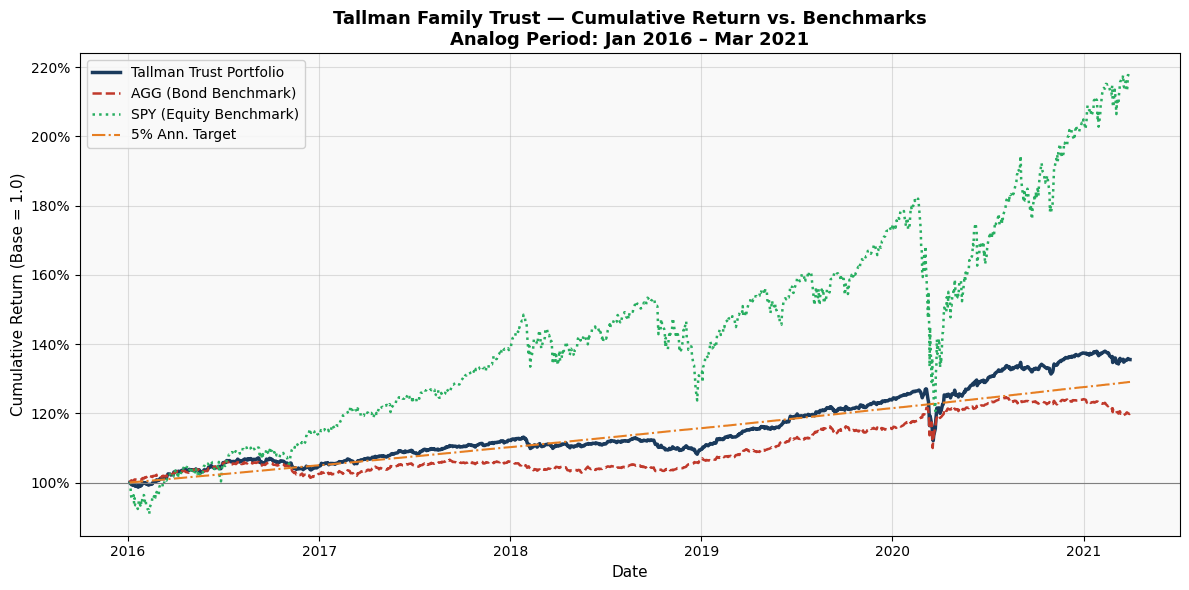

Saved: fig3_cumulative_returns.png


In [14]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(cum_port.index, cum_port.values,  color=COLORS['portfolio'], lw=2.5, label='Tallman Trust Portfolio')
ax.plot(cum_agg.index,  cum_agg.values,   color=COLORS['agg'],       lw=1.8, ls='--', label='AGG (Bond Benchmark)')
ax.plot(cum_spy.index,  cum_spy.values,   color=COLORS['sp500'],     lw=1.8, ls=':',  label='SPY (Equity Benchmark)')
ax.axhline(1.0, color='gray', lw=0.8, ls='-')

# Mark 5% annual target line
target_line = [(1 + TARGET_RETURN) ** (i / TRADING_DAYS) for i in range(len(cum_port))]
ax.plot(cum_port.index, target_line, color=COLORS['accent'], lw=1.5, ls='-.', label='5% Ann. Target')

ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
ax.set_title('Tallman Family Trust — Cumulative Return vs. Benchmarks\nAnalog Period: Jan 2016 – Mar 2021',
             fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Cumulative Return (Base = 1.0)')
ax.legend(loc='upper left', framealpha=0.9)
plt.tight_layout()
plt.savefig('fig3_cumulative_returns.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fig3_cumulative_returns.png")


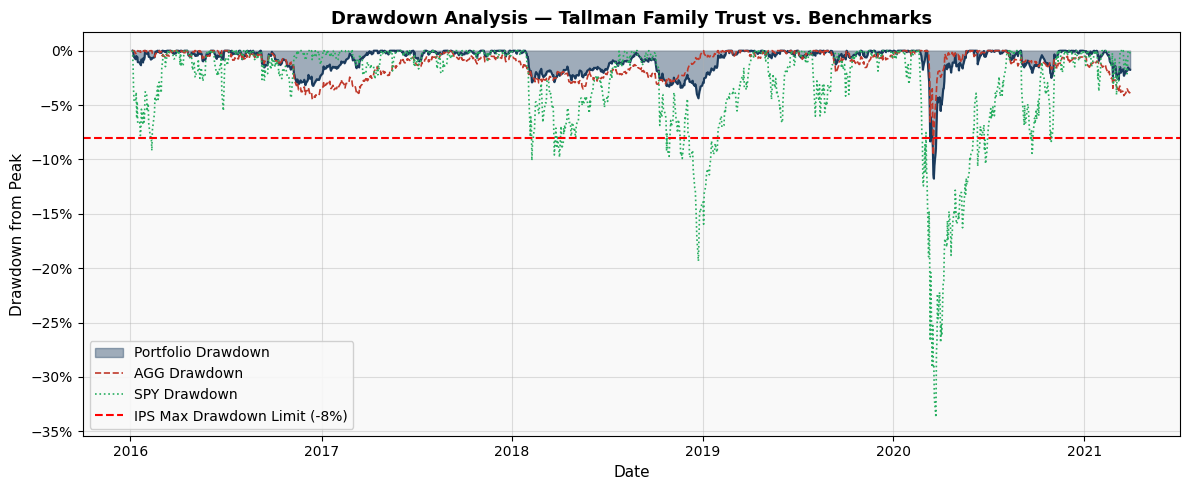

Saved: fig4_drawdown.png


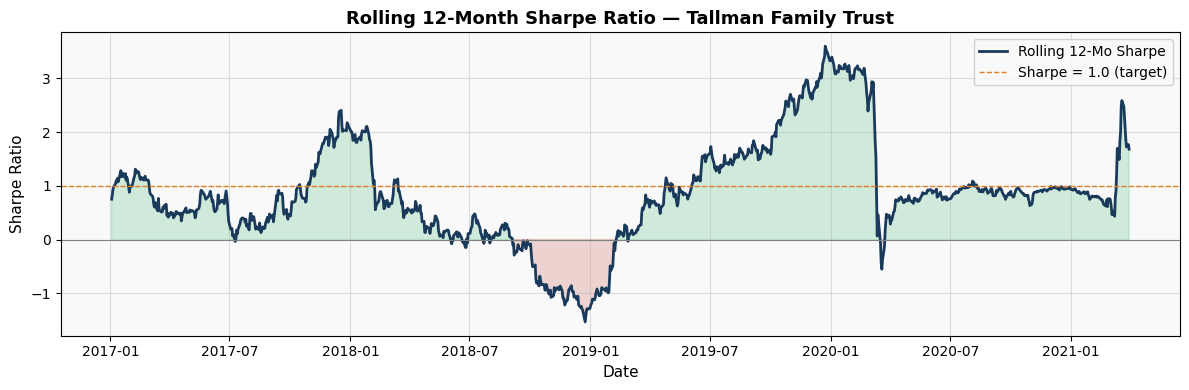

Saved: fig5_rolling_sharpe.png


In [15]:
def calc_drawdown(cum_series):
    roll_max = cum_series.cummax()
    return (cum_series - roll_max) / roll_max

dd_port = calc_drawdown(cum_port)
dd_agg  = calc_drawdown(cum_agg)
dd_spy  = calc_drawdown(cum_spy)

fig, ax = plt.subplots(figsize=(12, 5))
ax.fill_between(dd_port.index, dd_port.values, 0, alpha=0.4, color=COLORS['portfolio'], label='Portfolio Drawdown')
ax.plot(dd_port.index, dd_port.values, color=COLORS['portfolio'], lw=1.5)
ax.plot(dd_agg.index,  dd_agg.values,  color=COLORS['agg'],       lw=1.2, ls='--', label='AGG Drawdown')
ax.plot(dd_spy.index,  dd_spy.values,  color=COLORS['sp500'],     lw=1.2, ls=':',  label='SPY Drawdown')
ax.axhline(MAX_DRAWDOWN, color='red', lw=1.5, ls='--', label=f'IPS Max Drawdown Limit ({MAX_DRAWDOWN*100:.0f}%)')

ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
ax.set_title('Drawdown Analysis — Tallman Family Trust vs. Benchmarks', fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Drawdown from Peak')
ax.legend(loc='lower left', framealpha=0.9)
plt.tight_layout()
plt.savefig('fig4_drawdown.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fig4_drawdown.png")

window = 252
rolling_sharpe = (
    daily_port.rolling(window).mean() - RF_DAILY
) / daily_port.rolling(window).std() * np.sqrt(TRADING_DAYS)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(rolling_sharpe.index, rolling_sharpe.values, color=COLORS['portfolio'], lw=2, label='Rolling 12-Mo Sharpe')
ax.axhline(0, color='gray', lw=0.8)
ax.axhline(1, color=COLORS['accent'], lw=1, ls='--', label='Sharpe = 1.0 (target)')
ax.fill_between(rolling_sharpe.index, rolling_sharpe.values, 0,
                where=rolling_sharpe.values > 0, alpha=0.2, color=COLORS['sp500'])
ax.fill_between(rolling_sharpe.index, rolling_sharpe.values, 0,
                where=rolling_sharpe.values < 0, alpha=0.2, color=COLORS['agg'])
ax.set_title('Rolling 12-Month Sharpe Ratio — Tallman Family Trust', fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Sharpe Ratio')
ax.legend(framealpha=0.9)
plt.tight_layout()
plt.savefig('fig5_rolling_sharpe.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fig5_rolling_sharpe.png")

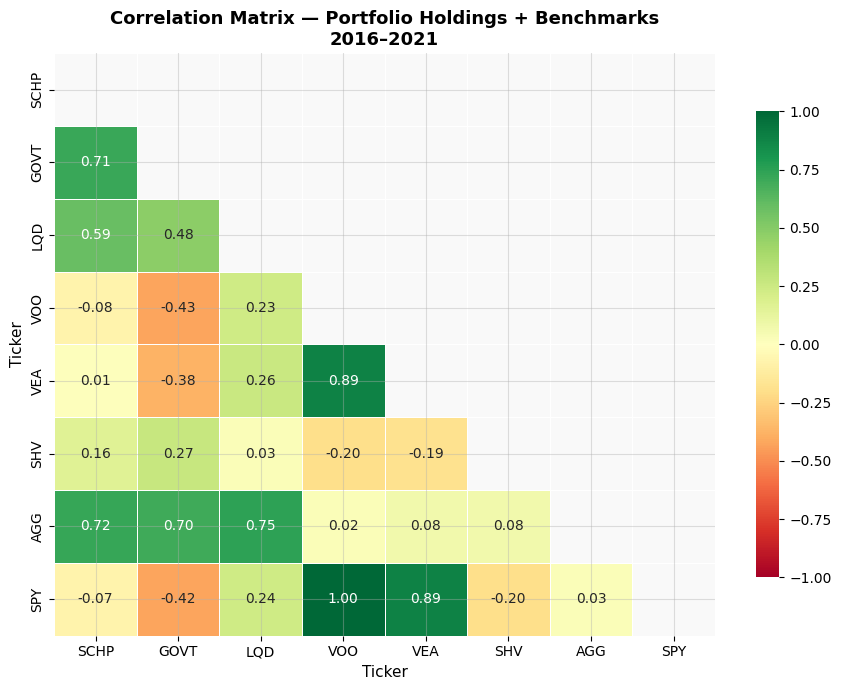

Saved: fig6_correlation_heatmap.png


In [16]:
corr_tickers = available + ['AGG', 'SPY']
corr_df = returns[corr_tickers].corr()
labels  = available + ['AGG (Benchmark)', 'SPY (Benchmark)']

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_df, dtype=bool))
sns.heatmap(
    corr_df, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
    vmin=-1, vmax=1, center=0,
    xticklabels=corr_tickers, yticklabels=corr_tickers,
    linewidths=0.5, ax=ax, cbar_kws={'shrink': 0.8}
)
ax.set_title('Correlation Matrix — Portfolio Holdings + Benchmarks\n2016–2021', fontweight='bold')
plt.tight_layout()
plt.savefig('fig6_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fig6_correlation_heatmap.png")

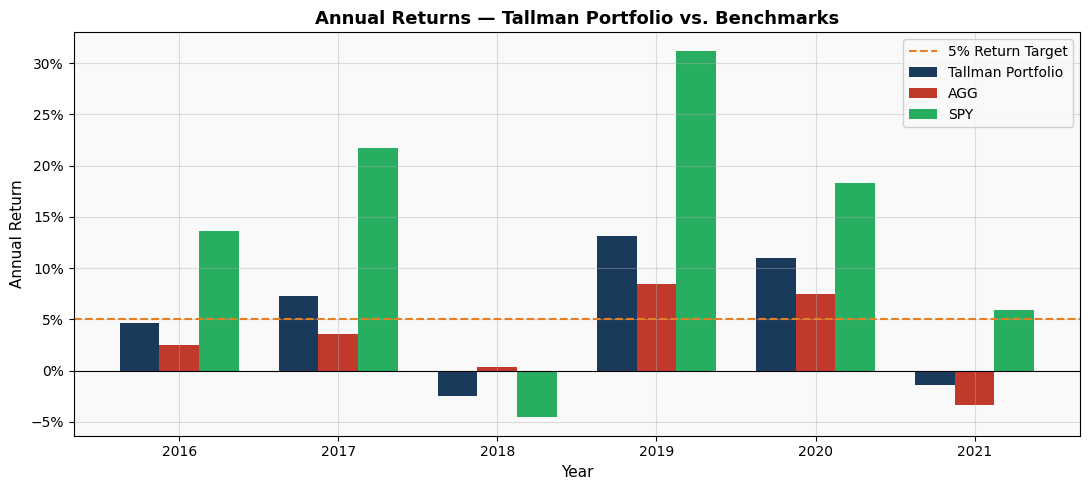

Saved: fig7_annual_returns.png


In [17]:
port_annual = daily_port.groupby(daily_port.index.year).apply(lambda x: (1+x).prod()-1)
agg_annual  = returns['AGG'].groupby(returns['AGG'].index.year).apply(lambda x: (1+x).prod()-1)
spy_annual  = returns['SPY'].groupby(returns['SPY'].index.year).apply(lambda x: (1+x).prod()-1)

years = port_annual.index.tolist()
x = np.arange(len(years))
w = 0.25

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(x - w, port_annual.values, width=w, color=COLORS['portfolio'], label='Tallman Portfolio')
ax.bar(x,     agg_annual.reindex(years).values, width=w, color=COLORS['agg'],   label='AGG')
ax.bar(x + w, spy_annual.reindex(years).values, width=w, color=COLORS['sp500'], label='SPY')
ax.axhline(TARGET_RETURN, color=COLORS['accent'], lw=1.5, ls='--', label='5% Return Target')
ax.axhline(0, color='black', lw=0.8)
ax.set_xticks(x)
ax.set_xticklabels(years)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
ax.set_title('Annual Returns — Tallman Portfolio vs. Benchmarks', fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Annual Return')
ax.legend(framealpha=0.9)
plt.tight_layout()
plt.savefig('fig7_annual_returns.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fig7_annual_returns.png")



=== FINAL PERFORMANCE SUMMARY ===
Label                 Tallman Portfolio AGG Benchmark SPY Benchmark
Ann. Return (Geo)                 5.98%         3.53%        15.96%
Ann. Volatility                   4.96%         4.55%        18.73%
Sharpe Ratio                      0.803         0.336         0.746
Max Drawdown                    -11.76%        -9.58%       -33.72%
VaR 95% (Daily)                 -0.490%       -0.458%       -1.875%
Cumulative Return                35.51%        19.88%       116.98%
Final Portfolio Value       $13,550,573   $11,988,078   $21,698,253
Meets 5% Target                     YES            NO           YES
Within Max Drawdown                  NO            NO            NO


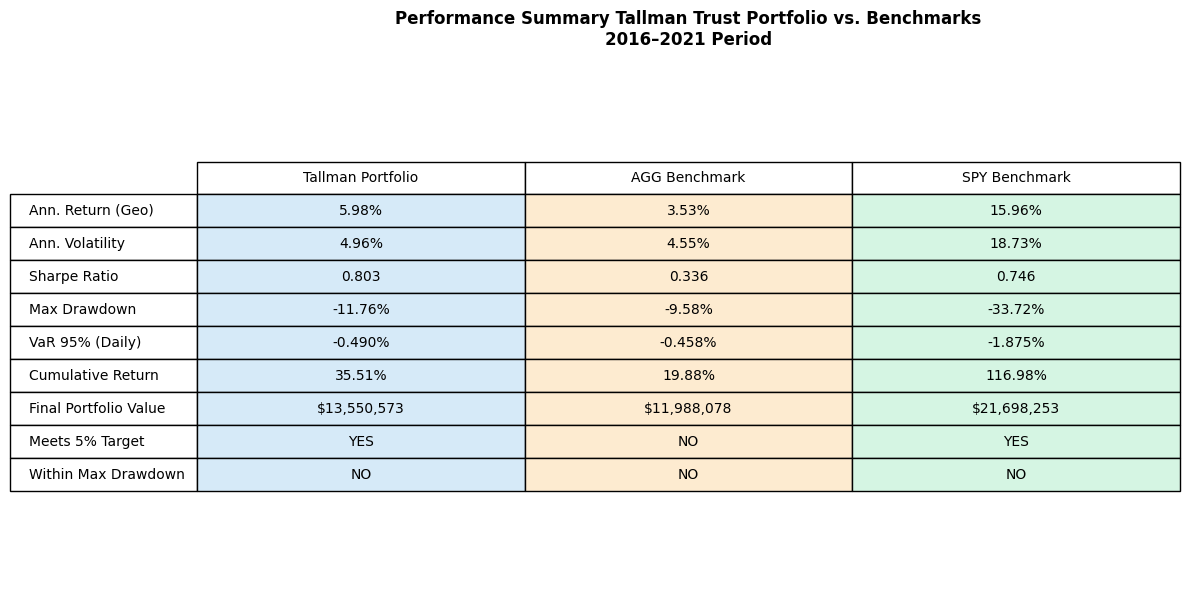

Saved: fig8_summary_metrics.png
Files: fig1_etf_screening_table.png through fig8_summary_metrics.png


In [20]:
def portfolio_metrics(daily_ret, label):
    n_years    = len(daily_ret) / TRADING_DAYS
    cum        = (1 + daily_ret).prod() - 1
    ann_geo    = (1 + cum) ** (1 / n_years) - 1
    ann_vol    = daily_ret.std() * np.sqrt(TRADING_DAYS)
    sharpe     = (ann_geo - RISK_FREE_ANNUAL) / ann_vol
    cum_val    = (1 + daily_ret).cumprod()
    roll_max   = cum_val.cummax()
    max_dd     = ((cum_val - roll_max) / roll_max).min()
    var_95_d   = norm.ppf(0.05, daily_ret.mean(), daily_ret.std())
    final_val  = FUND_VALUE * (1 + cum)
    return {
        'Label':               label,
        'Ann. Return (Geo)':   f"{ann_geo*100:.2f}%",
        'Ann. Volatility':     f"{ann_vol*100:.2f}%",
        'Sharpe Ratio':        f"{sharpe:.3f}",
        'Max Drawdown':        f"{max_dd*100:.2f}%",
        'VaR 95% (Daily)':     f"{var_95_d*100:.3f}%",
        'Cumulative Return':   f"{cum*100:.2f}%",
        'Final Portfolio Value':f"${final_val:,.0f}",
        'Meets 5% Target':     "YES" if ann_geo >= TARGET_RETURN else "NO",
        'Within Max Drawdown': "YES" if max_dd >= MAX_DRAWDOWN  else "NO",
    }

metrics_port = portfolio_metrics(daily_port,      'Tallman Portfolio')
metrics_agg  = portfolio_metrics(returns['AGG'],  'AGG Benchmark')
metrics_spy  = portfolio_metrics(returns['SPY'],  'SPY Benchmark')

summary_df = pd.DataFrame([metrics_port, metrics_agg, metrics_spy]).set_index('Label').T
print("\n=== FINAL PERFORMANCE SUMMARY ===")
print(summary_df.to_string())

fig, ax = plt.subplots(figsize=(12, 6))
ax.axis('off')
row_colors_sum = [
    ['#d6eaf8', '#fdebd0', '#d5f5e3'] for _ in range(len(summary_df))
]
tbl2 = ax.table(
    cellText=summary_df.values.tolist(),
    rowLabels=summary_df.index.tolist(),
    colLabels=summary_df.columns.tolist(),
    cellLoc='center', loc='center',
    cellColours=row_colors_sum,
)
tbl2.auto_set_font_size(False)
tbl2.set_fontsize(10)
tbl2.scale(1, 1.8)
ax.set_title('Performance Summary Tallman Trust Portfolio vs. Benchmarks\n2016–2021 Period',
             fontsize=12, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('fig8_summary_metrics.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fig8_summary_metrics.png")

print("Files: fig1_etf_screening_table.png through fig8_summary_metrics.png")